In [2]:
#%pip install kmapper
#%pip install xgboost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import kmapper as km
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split


In [4]:
df = pd.read_csv('NATA_clean.csv')
print(f"Datos: {df.shape}")

Datos: (2240, 29)


In [5]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [6]:
df['Marital_Status'] = df['Marital_Status'].replace(['Absurd', 'YOLO', 'Alone'], 'Single')

In [7]:
df.to_csv('data_cleaned.csv', index=False)
print("Datos limpios guardados")

Datos limpios guardados


## FEATURE ENGINEERING

In [8]:
df['Age'] = 2025 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Is_Couple'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)
education_map = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Education_Encoded'] = df['Education'].map(education_map)

In [9]:
print(f"   Age: {df['Age'].min()}-{df['Age'].max()} años")
print(f"   Total_Children: {df['Total_Children'].value_counts().to_dict()}")
print(f"   Is_Couple: {df['Is_Couple'].sum()} parejas de {len(df)}")

   Age: 29-132 años
   Total_Children: {1: 1128, 0: 638, 2: 421, 3: 53}
   Is_Couple: 1444 parejas de 2240


## Manage of Campaigns

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Is_Couple', 'Education_Encoded'],
      dtype='object')

In [12]:
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df['Total_Campaigns_Accepted'] = df[campaign_cols].sum(axis=1)
df['Campaign_Success_Rate'] = df['Total_Campaigns_Accepted'] / 5
df['Is_Marketing_Receptive'] = (df['Total_Campaigns_Accepted'] >= 1).astype(int)

In [13]:
print(f"   Total_Campaigns_Accepted: media = {df['Total_Campaigns_Accepted'].mean():.2f}")
print(f"   Campaign_Success_Rate: media = {df['Campaign_Success_Rate'].mean():.2f}")
print(f"   Is_Marketing_Receptive: {df['Is_Marketing_Receptive'].sum()} clientes receptivos")

   Total_Campaigns_Accepted: media = 0.30
   Campaign_Success_Rate: media = 0.06
   Is_Marketing_Receptive: 463 clientes receptivos


In [14]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
reference_date = pd.to_datetime('2025-10-27') 
df['Customer_Tenure'] = (reference_date - df['Dt_Customer']).dt.days


In [15]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spent'] = df[mnt_cols].sum(axis=1)
df['Avg_Purchase_Value'] = df['Total_Spent'] / (df['Total_Purchases'] + 1)  # +1 para evitar división por cero


print(f"Total_Purchases: media = {df['Total_Purchases'].mean():.2f}")
print(f"Customer_Tenure: {df['Customer_Tenure'].min()}-{df['Customer_Tenure'].max()} días")
print(f"Total_Spent: media = ${df['Total_Spent'].mean():.2f}")
print(f"Avg_Purchase_Value: media = ${df['Avg_Purchase_Value'].mean():.2f}")

Total_Purchases: media = 14.86
Customer_Tenure: 4138-4837 días
Total_Spent: media = $605.80
Avg_Purchase_Value: media = $30.93


In [16]:
new_features = ['Age', 'Total_Children', 'Is_Couple', 'Education_Encoded',
                'Total_Campaigns_Accepted', 'Campaign_Success_Rate', 'Is_Marketing_Receptive',
                'Total_Purchases', 'Customer_Tenure', 'Total_Spent', 'Avg_Purchase_Value']


In [17]:
for i, feat in enumerate(new_features, 1):
    print(f"   {i}. {feat}")

print(f"\nDimensiones finales: {df.shape}")

   1. Age
   2. Total_Children
   3. Is_Couple
   4. Education_Encoded
   5. Total_Campaigns_Accepted
   6. Campaign_Success_Rate
   7. Is_Marketing_Receptive
   8. Total_Purchases
   9. Customer_Tenure
   10. Total_Spent
   11. Avg_Purchase_Value

Dimensiones finales: (2240, 40)


In [18]:
df.to_csv('data_with_features.csv', index=False)

## K-MEANS Features

In [19]:
features_kmeans = [
    'Income', 'Age', 'Total_Children', 'Education_Encoded', 'Is_Couple',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 
    'NumDealsPurchases',
    'Recency', 'NumWebVisitsMonth', 'Customer_Tenure',
    'Total_Campaigns_Accepted', 'Campaign_Success_Rate',
    'Complain'
]

In [20]:
print(f"\n Features selected for K-means: {len(features_kmeans)}")
for i, feat in enumerate(features_kmeans, 1):
    print(f"   {i}. {feat}")


 Features selected for K-means: 15
   1. Income
   2. Age
   3. Total_Children
   4. Education_Encoded
   5. Is_Couple
   6. NumWebPurchases
   7. NumCatalogPurchases
   8. NumStorePurchases
   9. NumDealsPurchases
   10. Recency
   11. NumWebVisitsMonth
   12. Customer_Tenure
   13. Total_Campaigns_Accepted
   14. Campaign_Success_Rate
   15. Complain


In [21]:
print("\nSummary features:")
print(df[features_kmeans].describe().T[['mean', 'std', 'min', 'max']])


Summary features:
                                  mean           std     min       max
Income                    52247.251354  25037.797168  1730.0  666666.0
Age                          56.194196     11.984069    29.0     132.0
Total_Children                0.950446      0.751803     0.0       3.0
Education_Encoded             3.460268      1.004337     1.0       5.0
Is_Couple                     0.644643      0.478728     0.0       1.0
NumWebPurchases               4.084821      2.778714     0.0      27.0
NumCatalogPurchases           2.662054      2.923101     0.0      28.0
NumStorePurchases             5.790179      3.250958     0.0      13.0
NumDealsPurchases             2.325000      1.932238     0.0      15.0
Recency                      49.109375     28.962453     0.0      99.0
NumWebVisitsMonth             5.316518      2.426645     0.0      20.0
Customer_Tenure            4491.582143    202.122512  4138.0    4837.0
Total_Campaigns_Accepted      0.297768      0.678381     0

In [22]:
X = df[features_kmeans].values

In [23]:

print(f"\nDimensiones de X: {X.shape}")



Dimensiones de X: (2240, 15)


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n Features with StandardScaler")
print(f"Mean after scaling: {X_scaled.mean():.6f}")
print(f"Std después scaling: {X_scaled.std():.6f}")


 Features with StandardScaler
Mean after scaling: 0.000000
Std después scaling: 1.000000


In [25]:
df_scaled = pd.DataFrame(X_scaled, columns=features_kmeans)


In [26]:
np.save('X_scaled.npy', X_scaled)
with open('feature_names.txt', 'w') as f:
    for feat in features_kmeans:
        f.write(f"{feat}\n")

In [27]:
np.save('feature_names.npy', features_kmeans)

In [28]:
X_scaled = np.load('X_scaled.npy')

In [29]:
print(f"\n{X_scaled.shape}")


(2240, 15)


## K OPTIME

In [30]:
k_range = range(2, 11) 
inertias = []

print("\nInertia fo each K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"   K={k}: Inercia={kmeans.inertia_:.2f}")


Inertia fo each K...
   K=2: Inercia=27640.18
   K=3: Inercia=25028.46
   K=4: Inercia=22932.96
   K=5: Inercia=20774.33
   K=6: Inercia=19725.70
   K=7: Inercia=18872.10
   K=8: Inercia=18221.35
   K=9: Inercia=17729.43
   K=10: Inercia=17400.01


In [31]:
silhouette_scores = []

print("\nSilhouette Score for each K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"   K={k}: Silhouette={score:.4f}")


Silhouette Score for each K...
   K=2: Silhouette=0.1910
   K=3: Silhouette=0.1704
   K=4: Silhouette=0.1718
   K=5: Silhouette=0.1799
   K=6: Silhouette=0.1301
   K=7: Silhouette=0.1239
   K=8: Silhouette=0.1211
   K=9: Silhouette=0.1181
   K=10: Silhouette=0.1124


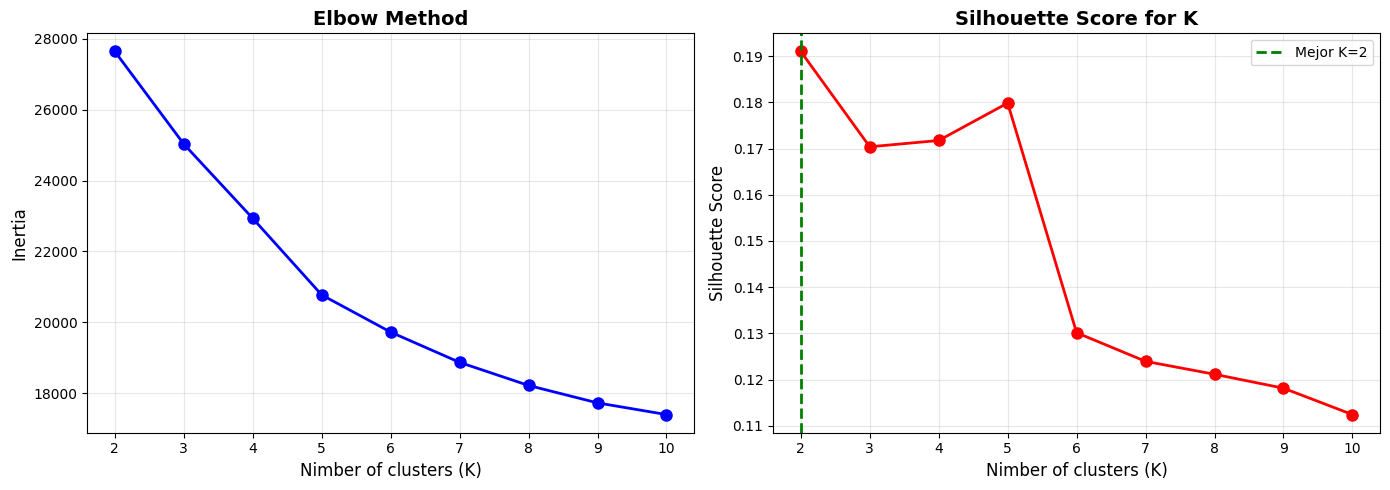

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nimber of clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Nimber of clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)
# Marcar el mejor K según Silhouette
best_k_idx = np.argmax(silhouette_scores)
best_k = list(k_range)[best_k_idx]
axes[1].axvline(best_k, color='green', linestyle='--', linewidth=2, 
                label=f'Mejor K={best_k}')
axes[1].legend()

plt.tight_layout()

In [33]:
print(f"\n Best K according Silhouette Score: K={best_k} (Score={silhouette_scores[best_k_idx]:.4f})")




 Best K according Silhouette Score: K=2 (Score=0.1910)


In [34]:

results = {
    'k_values': list(k_range),
    'inertias': inertias,
    'silhouette_scores': silhouette_scores,
    'best_k': best_k
}
np.save('k_optimization_results.npy', results)

In [35]:
df = pd.read_csv('data_with_features.csv')
feature_names = np.load('feature_names.npy', allow_pickle=True)

### 2 clusters

In [36]:
df2 = df.copy()

In [37]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster_K2'] = kmeans_2.fit_predict(X_scaled)


print(f"\nDistribution of clusters:")
print(df['Cluster_K2'].value_counts().sort_index())


Distribution of clusters:
Cluster_K2
0     958
1    1282
Name: count, dtype: int64


In [38]:
analysis_cols = ['Income', 'Age', 'Total_Children', 'Total_Purchases', 
                 'Total_Spent', 'Total_Campaigns_Accepted', 'Recency']

print("\nProfile of cluster (K=2):")
cluster_profile_k2 = df.groupby('Cluster_K2')[analysis_cols].mean()
print(cluster_profile_k2.round(2))


Profile of cluster (K=2):
              Income    Age  Total_Children  Total_Purchases  Total_Spent  \
Cluster_K2                                                                  
0           71468.64  58.23            0.50            21.23      1169.53   
1           37883.68  54.67            1.28            10.10       184.54   

            Total_Campaigns_Accepted  Recency  
Cluster_K2                                     
0                               0.58    49.54  
1                               0.09    48.78  


In [39]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

print("\nAverage spent per cluster (K=2):")
spending_k2 = df.groupby('Cluster_K2')[mnt_cols].mean()
print(spending_k2.round(2))


Average spent per cluster (K=2):
            MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster_K2                                                          
0             584.01      51.72           336.31            73.04   
1              94.65       7.31            40.39            10.99   

            MntSweetProducts  MntGoldProds  
Cluster_K2                                  
0                      52.94         71.51  
1                       7.72         23.48  


### 4 clusters

In [40]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_K4'] = kmeans_4.fit_predict(X_scaled)

print(f"\n K-means with K=4")
print(f"\nDistribution of clusters:")
print(df['Cluster_K4'].value_counts().sort_index())


 K-means with K=4

Distribution of clusters:
Cluster_K4
0    135
1    524
2    977
3    604
Name: count, dtype: int64


In [41]:
print("\nProfile of cluster (K=4):")
cluster_profile_k4 = df.groupby('Cluster_K4')[analysis_cols].mean()
print(cluster_profile_k4.round(2))


Profile of cluster (K=4):
              Income    Age  Total_Children  Total_Purchases  Total_Spent  \
Cluster_K4                                                                  
0           79160.41  54.66            0.32            21.10      1535.48   
1           54461.78  59.43            1.30            21.06       712.06   
2           34303.24  53.32            1.23             7.50        92.07   
3           73336.01  58.37            0.34            19.99      1136.80   

            Total_Campaigns_Accepted  Recency  
Cluster_K4                                     
0                               2.49    48.38  
1                               0.20    49.23  
2                               0.08    49.15  
3                               0.24    49.10  


In [42]:


print("\nAverage spent per category (K=4):")
spending_k4 = df.groupby('Cluster_K4')[mnt_cols].mean()
print(spending_k4.round(2))


Average spent per category (K=4):
            MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster_K4                                                          
0             882.56      50.14           399.16            71.19   
1             424.92      25.31           140.27            33.11   
2              37.12       5.10            22.72             7.20   
3             501.23      56.13           371.49            82.89   

            MntSweetProducts  MntGoldProds  
Cluster_K4                                  
0                      57.44         75.00  
1                      25.89         62.57  
2                       5.08         14.84  
3                      56.86         68.20  


### 3 clusters

In [43]:

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_K3'] = kmeans_3.fit_predict(X_scaled)

print(f"\n K-means with K=3")
print(f"\nDistribution of clusters:")
print(df['Cluster_K3'].value_counts().sort_index())



 K-means with K=3

Distribution of clusters:
Cluster_K3
0    1077
1     889
2     274
Name: count, dtype: int64


### 5 clusters

In [44]:

kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_K5'] = kmeans_5.fit_predict(X_scaled)

print(f"\n K-means with K=5")
print(f"\nDistribution of clusters:")
print(df['Cluster_K5'].value_counts().sort_index())



 K-means with K=5

Distribution of clusters:
Cluster_K5
0    136
1    961
2     21
3    522
4    600
Name: count, dtype: int64


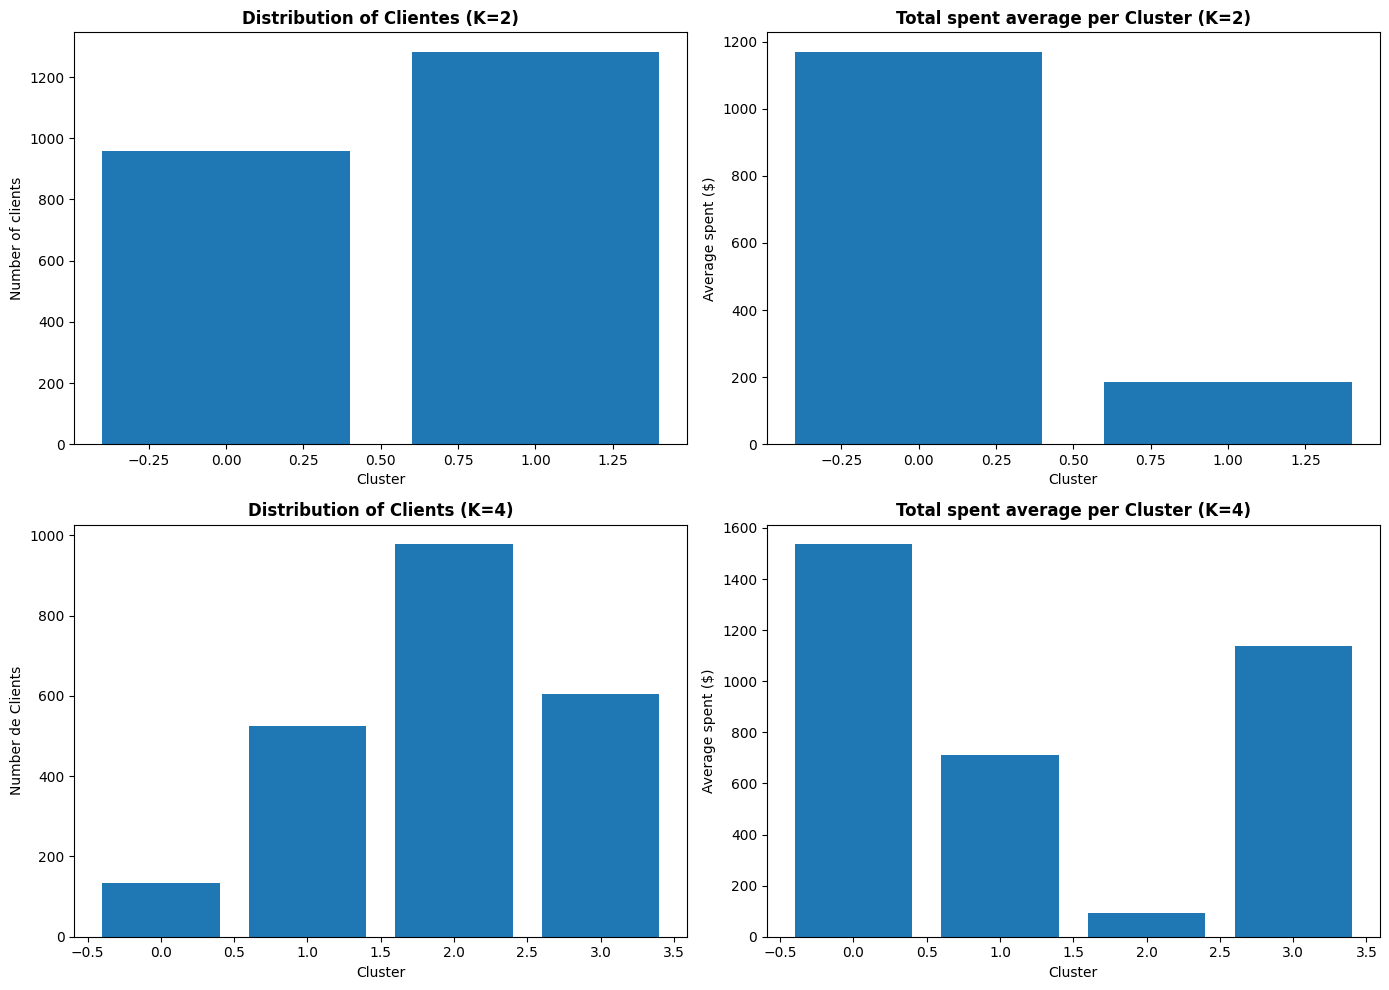

In [45]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K=2: Distribución
axes[0, 0].bar(df['Cluster_K2'].value_counts().sort_index().index,
               df['Cluster_K2'].value_counts().sort_index().values)
axes[0, 0].set_title('Distribution of Clientes (K=2)', fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
# K=2: Gasto promedio
axes[0, 0].set_ylabel('Number of clients')
spending_k2['Total'] = spending_k2.sum(axis=1)
axes[0, 1].bar(spending_k2.index, spending_k2['Total'])
axes[0, 1].set_title('Total spent average per Cluster (K=2)', fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average spent ($)')

# K=4: Distribución
axes[1, 0].bar(df['Cluster_K4'].value_counts().sort_index().index,
               df['Cluster_K4'].value_counts().sort_index().values)
axes[1, 0].set_title('Distribution of Clients (K=4)', fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Number de Clients')

# K=4: Gasto promedio
spending_k4['Total'] = spending_k4.sum(axis=1)
axes[1, 1].bar(spending_k4.index, spending_k4['Total'])
axes[1, 1].set_title('Total spent average per Cluster (K=4)', fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Average spent ($)')
plt.tight_layout()

In [46]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Is_Couple', 'Education_Encoded',
       'Total_Campaigns_Accepted', 'Campaign_Success_Rate',
       'Is_Marketing_Receptive', 'Total_Purchases', 'Customer_Tenure',
       'Total_Spent', 'Avg_Purchase_Value', 'Cluster_K2', 'Cluster_K4',
       'Cluster_K3', 'Cluster_K5'],
      dtype='object')

In [47]:
df.to_csv('data_with_clusters.csv', index=False)

In [48]:
df = pd.read_csv('data_with_clusters.csv')

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Variance explained: 36.0%


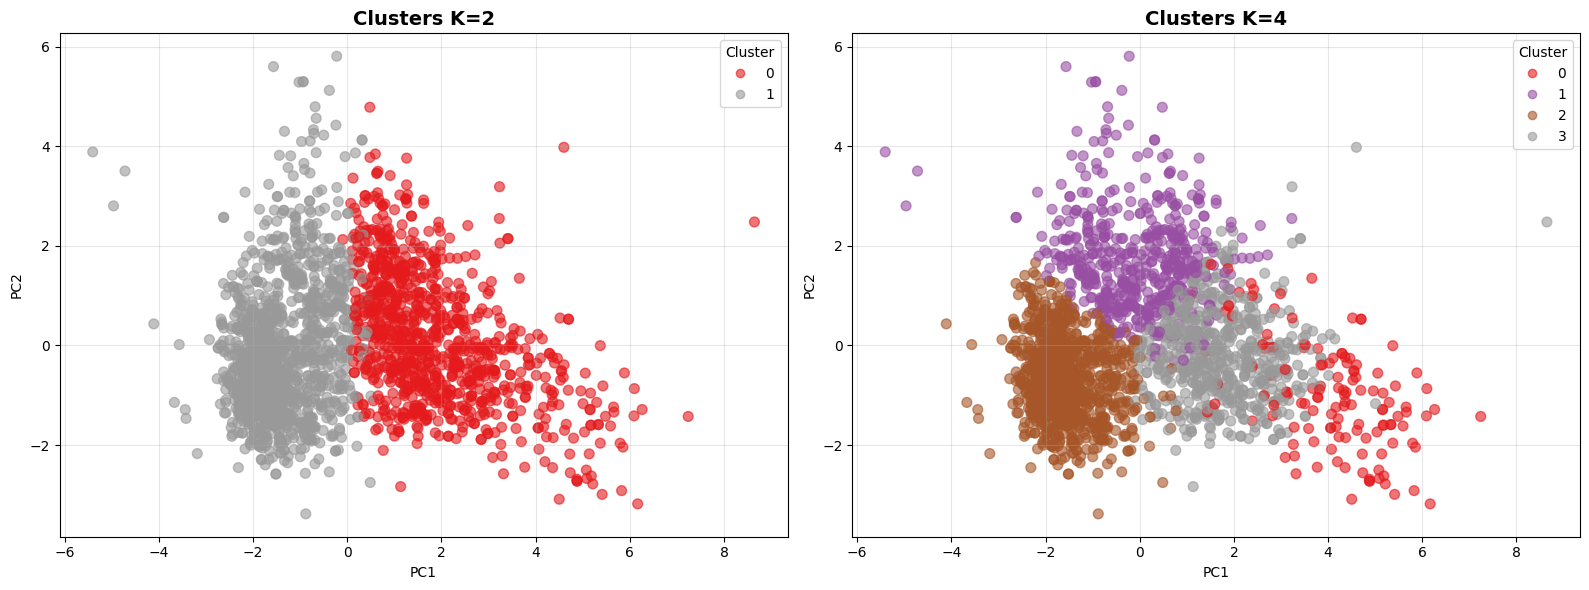

In [50]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K=2
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=df['Cluster_K2'], cmap='Set1', 
                           alpha=0.6, s=50)
axes[0].set_title('Clusters K=2', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(*scatter1.legend_elements(), title="Cluster")
axes[0].grid(True, alpha=0.3)

# K=4
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=df['Cluster_K4'], cmap='Set1', 
                           alpha=0.6, s=50)
axes[1].set_title('Clusters K=4', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(*scatter2.legend_elements(), title="Cluster")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()


plt.show()

✓ Guardado: clusters_3D.png


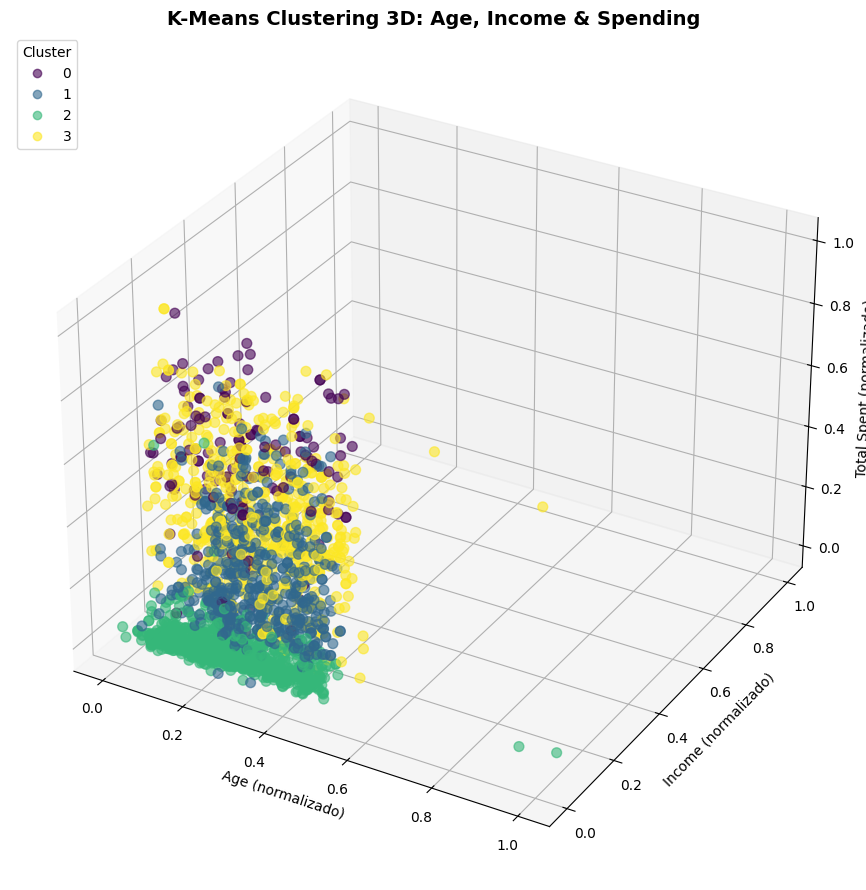

In [51]:

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
age_norm = (df['Age'] - df['Age'].min()) / (df['Age'].max() - df['Age'].min())
income_norm = (df['Income'] - df['Income'].min()) / (df['Income'].max() - df['Income'].min())
spent_norm = (df['Total_Spent'] - df['Total_Spent'].min()) / (df['Total_Spent'].max() - df['Total_Spent'].min())

# Scatter plot con K=4
scatter = ax.scatter(age_norm, income_norm, spent_norm,
                     c=df['Cluster_K4'], cmap='viridis', 
                     s=50, alpha=0.6)

ax.set_xlabel('Age (normalizado)', fontsize=10)
ax.set_ylabel('Income (normalizado)', fontsize=10)
ax.set_zlabel('Total Spent (normalizado)', fontsize=10)
ax.set_title('K-Means Clustering 3D: Age, Income & Spending', 
             fontsize=14, fontweight='bold')

# Leyenda
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc='upper left')

plt.tight_layout()
plt.savefig('clusters_3D.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: clusters_3D.png")

plt.show()

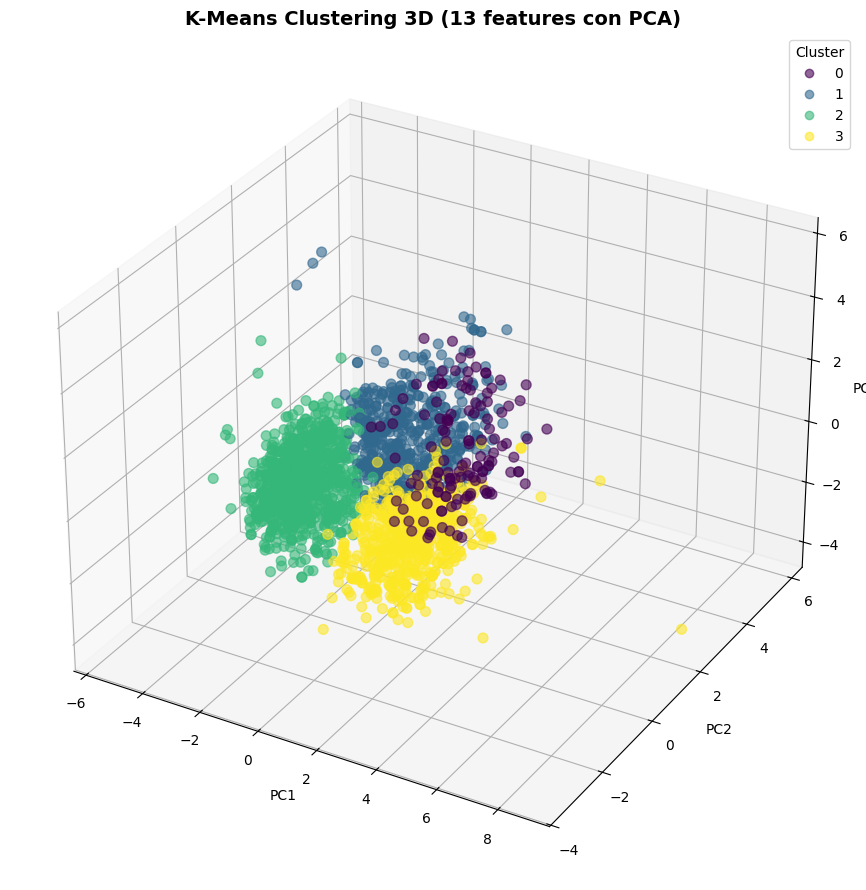

In [52]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=df['Cluster_K4'], cmap='viridis', 
                     s=50, alpha=0.6)

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('PC3', fontsize=10)
ax.set_title('K-Means Clustering 3D (13 features con PCA)', 
             fontsize=14, fontweight='bold')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.show()

In [53]:
mapper = km.KeplerMapper(verbose=1)
pca = PCA(n_components=2)
lens = pca.fit_transform(X_scaled)
graph = mapper.map(lens, X_scaled,
                   cover=km.Cover(n_cubes=20, perc_overlap=0.6), 
                   clusterer=DBSCAN(eps=2.0, min_samples=10))    
html = mapper.visualize(graph,
                        path_html="mapper_final.html",
                        title="Mapper - Segmentación de Clientes",
                        color_values=df['Total_Spent'].values,
                        color_function_name='Total Spent ($)')


KeplerMapper(verbose=1)
Mapping on data shaped (2240, 15) using lens shaped (2240, 2)

Creating 400 hypercubes.

Created 768 edges and 117 nodes in 0:00:00.775269.
Wrote visualization to: mapper_final.html


In [54]:
mapper = km.KeplerMapper(verbose=1)

pca = PCA(n_components=2)
lens = pca.fit_transform(X_scaled)

# Grafo
graph = mapper.map(lens, X_scaled,
                   cover=km.Cover(n_cubes=20, perc_overlap=0.6),
                   clusterer=DBSCAN(eps=2.0, min_samples=10))

# NORMALIZAR las variables de color (usando percentiles para evitar outliers)
def normalize_robust(x):
    """Normaliza usando percentiles 5-95 para evitar outliers extremos"""
    p5 = np.percentile(x, 5)
    p95 = np.percentile(x, 95)
    x_clipped = np.clip(x, p5, p95)
    return (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min())

# Crear matriz normalizada
color_matrix = np.column_stack([
    normalize_robust(df['Total_Spent'].values),
    normalize_robust(df['MntWines'].values),
    normalize_robust(df['MntFruits'].values),
    normalize_robust(df['MntMeatProducts'].values),
    normalize_robust(df['MntFishProducts'].values),
    normalize_robust(df['MntSweetProducts'].values),
    normalize_robust(df['MntGoldProds'].values),
    normalize_robust(df['Income'].values),
    normalize_robust(df['Age'].values),
    normalize_robust(df['Total_Campaigns_Accepted'].values)
])

color_names = ['Total_Spent', 'MntWines', 'MntFruits', 'MntMeatProducts',
               'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
               'Income', 'Age', 'Total_Campaigns_Accepted']

html = mapper.visualize(graph,
                        path_html="mapper_normalized.html",
                        title="Mapper - Normalizado",
                        color_values=color_matrix,
                        color_function_name=color_names)


KeplerMapper(verbose=1)
Mapping on data shaped (2240, 15) using lens shaped (2240, 2)

Creating 400 hypercubes.

Created 768 edges and 117 nodes in 0:00:00.546942.
Wrote visualization to: mapper_normalized.html


In [142]:
df_clusters = pd.read_csv('data_with_clusters.csv')

In [143]:
df_clusters.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Is_Couple', 'Education_Encoded',
       'Total_Campaigns_Accepted', 'Campaign_Success_Rate',
       'Is_Marketing_Receptive', 'Total_Purchases', 'Customer_Tenure',
       'Total_Spent', 'Avg_Purchase_Value', 'Cluster_K2', 'Cluster_K4',
       'Cluster_K3', 'Cluster_K5'],
      dtype='object')

In [144]:


def profile_cluster(df, cluster_col='Cluster_K3'):
 
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster_id]
        
   
        print(f" CLUSTER {cluster_id}")
        print(f"   Size: {len(cluster_data):,} customers ({len(cluster_data)/len(df)*100:.1f}%)")
     
        
      
        print(" DEMOGRAPHICS:")
        print(f"  • Average age: {cluster_data['Age'].mean():.1f} years")
        print(f"  • Average income: ${cluster_data['Income'].mean():,.0f}")
        print(f"  • Most common education: {cluster_data['Education'].mode()[0]}")
        print(f"  • Most common marital status: {cluster_data['Marital_Status'].mode()[0]}")
        print(f"  • % with partner: {cluster_data['Is_Couple'].mean()*100:.1f}%")
        print(f"  • Average children at home: {cluster_data['Total_Children'].mean():.2f}")
        
 
        print(f"\n SPENDING & PURCHASES:")
        print(f"  • Total average spending: ${cluster_data['Total_Spent'].mean():,.0f}")
        print(f"  • Average purchase value: ${cluster_data['Avg_Purchase_Value'].mean():.2f}")
        print(f"  • Total purchases: {cluster_data['Total_Purchases'].mean():.1f}")
        print(f"  • Web purchases: {cluster_data['NumWebPurchases'].mean():.1f}")
        print(f"  • Catalog purchases: {cluster_data['NumCatalogPurchases'].mean():.1f}")
        print(f"  • Store purchases: {cluster_data['NumStorePurchases'].mean():.1f}")
        print(f"  • Web visits/month: {cluster_data['NumWebVisitsMonth'].mean():.1f}")
        
    
        print(f"\n MOST PURCHASED PRODUCTS:")
        print(f"  • Wines: ${cluster_data['MntWines'].mean():.0f}")
        print(f"  • Meat: ${cluster_data['MntMeatProducts'].mean():.0f}")
        print(f"  • Fish: ${cluster_data['MntFishProducts'].mean():.0f}")
        print(f"  • Fruits: ${cluster_data['MntFruits'].mean():.0f}")
        print(f"  • Sweets: ${cluster_data['MntSweetProducts'].mean():.0f}")
        print(f"  • Gold: ${cluster_data['MntGoldProds'].mean():.0f}")
        
       
        print(f"\n MARKETING RESPONSE:")
        print(f"  • Campaign success rate: {cluster_data['Campaign_Success_Rate'].mean()*100:.1f}%")
        print(f"  • Total campaigns accepted: {cluster_data['Total_Campaigns_Accepted'].mean():.2f}")
        print(f"  • % Receptive to marketing: {cluster_data['Is_Marketing_Receptive'].mean()*100:.1f}%")
        print(f"  • Purchases with discount: {cluster_data['NumDealsPurchases'].mean():.1f}")
        print(f"  • Complaints: {cluster_data['Complain'].sum()} ({cluster_data['Complain'].mean()*100:.1f}%)")
        
      
        print(f"\n  OTHER METRICS:")
        print(f"  • Customer tenure: {cluster_data['Customer_Tenure'].mean():.0f} days")
        print(f"  • Recency (days since last purchase): {cluster_data['Recency'].mean():.1f}")

# Run
profile_cluster(df_clusters, 'Cluster_K3')

 CLUSTER 0
   Size: 1,077 customers (48.1%)
 DEMOGRAPHICS:
  • Average age: 53.5 years
  • Average income: $34,968
  • Most common education: Graduation
  • Most common marital status: Married
  • % with partner: 64.8%
  • Average children at home: 1.27

 SPENDING & PURCHASES:
  • Total average spending: $112
  • Average purchase value: $10.97
  • Total purchases: 8.3
  • Web purchases: 2.3
  • Catalog purchases: 0.6
  • Store purchases: 3.3
  • Web visits/month: 6.6

 MOST PURCHASED PRODUCTS:
  • Wines: $49
  • Meat: $27
  • Fish: $8
  • Fruits: $5
  • Sweets: $5
  • Gold: $18

 MARKETING RESPONSE:
  • Campaign success rate: 1.8%
  • Total campaigns accepted: 0.09
  • % Receptive to marketing: 8.6%
  • Purchases with discount: 2.2
  • Complaints: 13 (1.2%)

  OTHER METRICS:
  • Customer tenure: 4469 days
  • Recency (days since last purchase): 49.5
 CLUSTER 1
   Size: 889 customers (39.7%)
 DEMOGRAPHICS:
  • Average age: 59.3 years
  • Average income: $64,578
  • Most common education

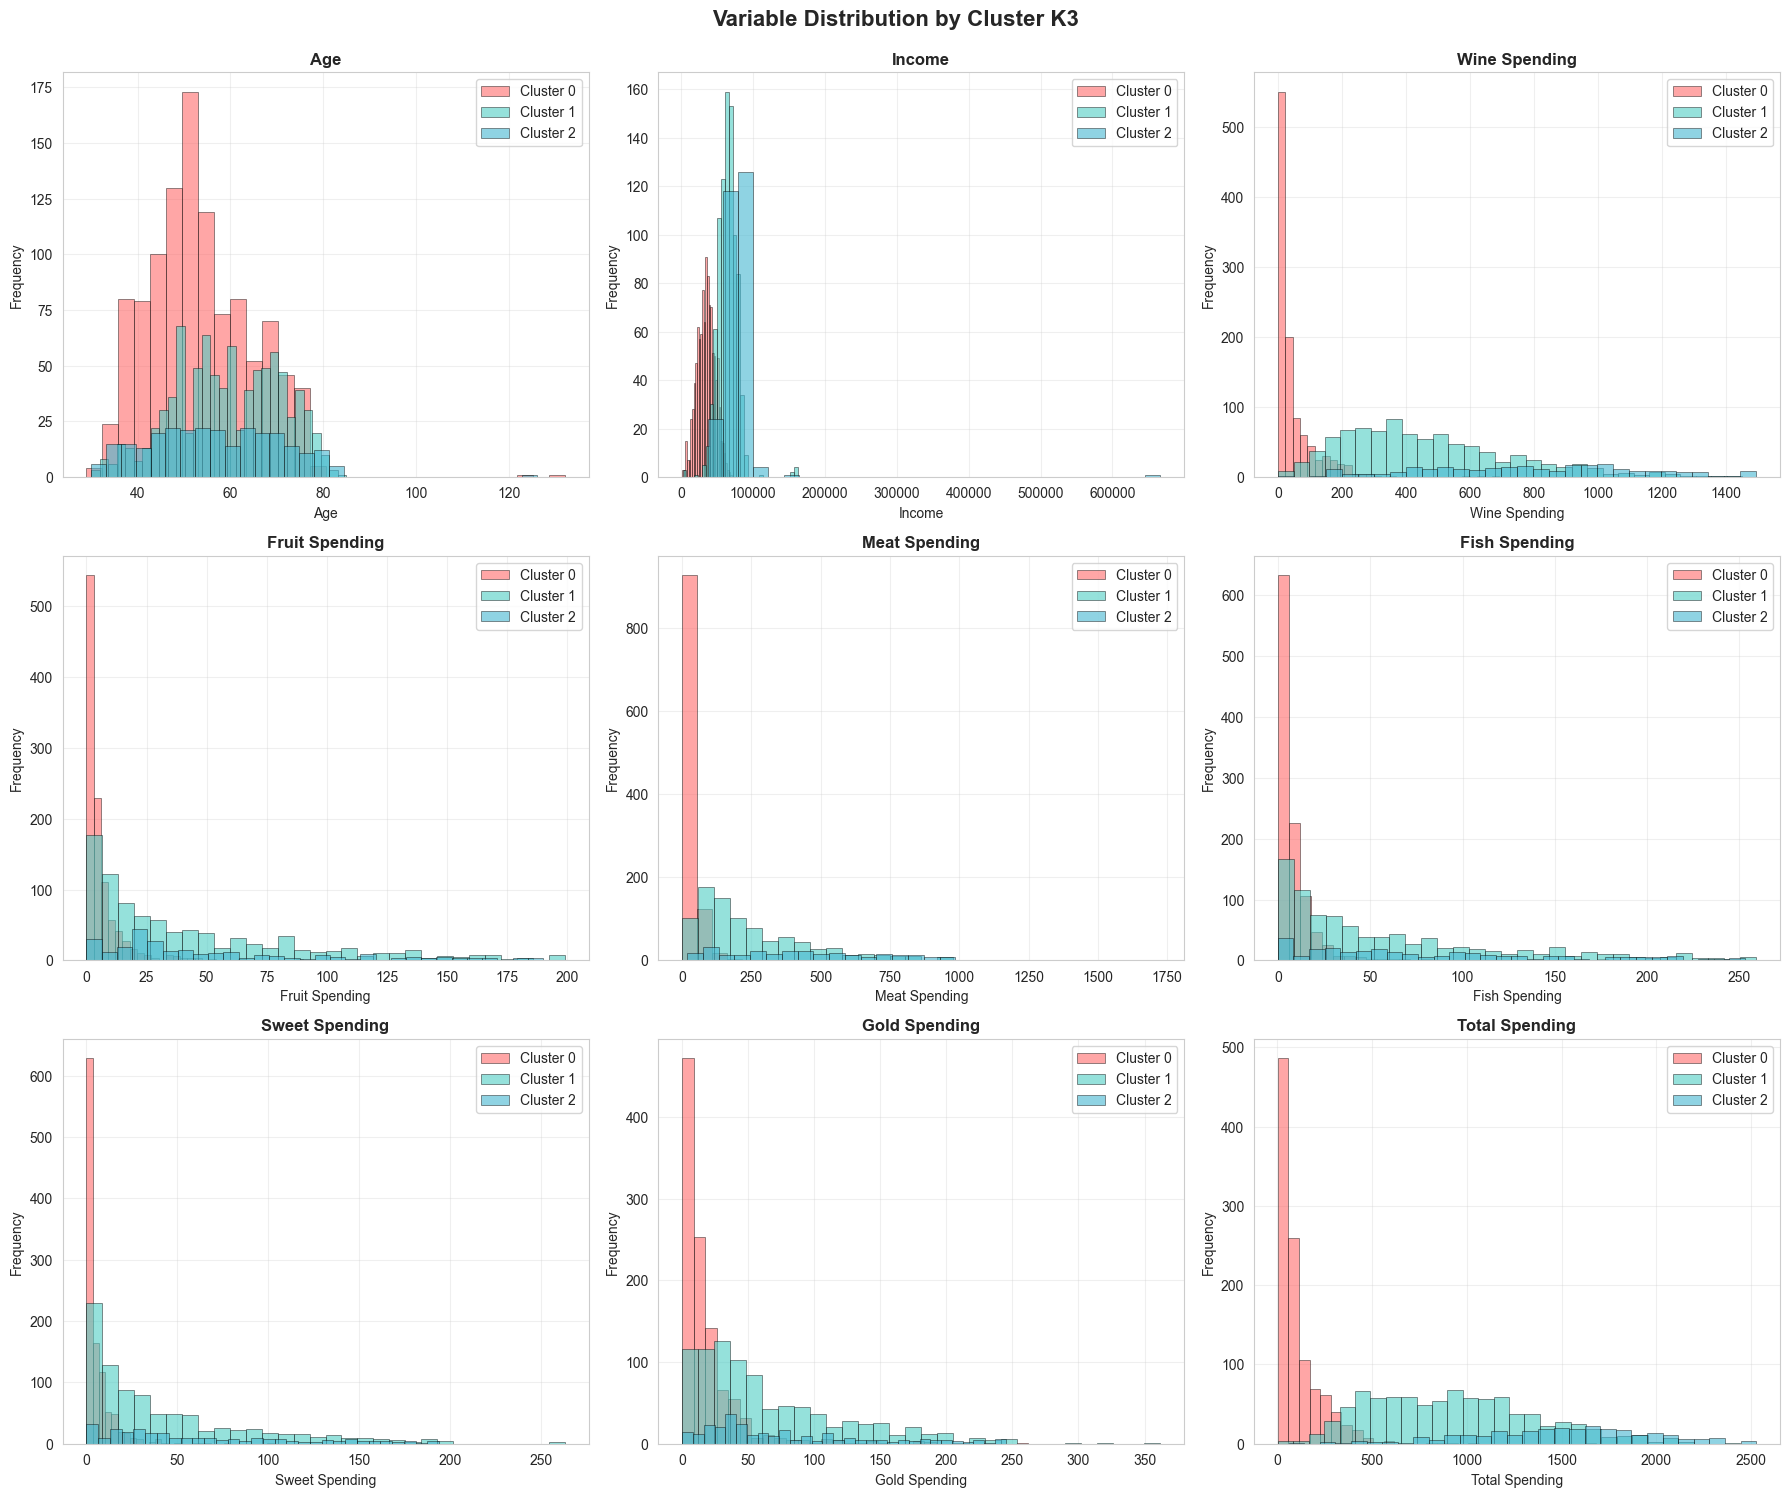

In [146]:
import seaborn as sns

sns.set_style("whitegrid")
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Colors for 3 clusters


fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Variable Distribution by Cluster K3', fontsize=16, fontweight='bold', y=0.995)

variables = [
    ('Age', 'Age'),
    ('Income', 'Income'),
    ('MntWines', 'Wine Spending'),
    ('MntFruits', 'Fruit Spending'),
    ('MntMeatProducts', 'Meat Spending'),
    ('MntFishProducts', 'Fish Spending'),
    ('MntSweetProducts', 'Sweet Spending'),
    ('MntGoldProds', 'Gold Spending'),
    ('Total_Spent', 'Total Spending')
]

for idx, (var, label) in enumerate(variables):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    for cluster_id in sorted(df_clusters['Cluster_K3'].unique()):
        data = df_clusters[df_clusters['Cluster_K3'] == cluster_id][var]
        ax.hist(data, alpha=0.6, label=f'Cluster {cluster_id}', 
                bins=30, color=colors[cluster_id], edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## FORECASTING

In [127]:
df_clusters = pd.read_csv('data_with_clusters.csv')

columns_forecast = ['Cluster_K3', 'Dt_Customer', 'MntWines', 'MntFruits', 'MntMeatProducts',
                    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'] 
df_fc = df_clusters[columns_forecast].copy()

df_fc['Dt_Customer'] = pd.to_datetime(df_fc['Dt_Customer'])
df_fc['Month'] = df_fc['Dt_Customer'].dt.month
df_fc['Year'] = df_fc['Dt_Customer'].dt.year

df_fc = df_fc.drop('Dt_Customer', axis=1)

print(df_fc.head())

   Cluster_K3  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0           1       635         88              546              172   
1           0        11          1                6                2   
2           1       426         49              127              111   
3           0        11          4               20               10   
4           1       173         43              118               46   

   MntSweetProducts  MntGoldProds  Month  Year  
0                88            88      9  2012  
1                 1             6      3  2014  
2                21            42      8  2013  
3                 3             5      2  2014  
4                27            15      1  2014  


In [128]:
df_cluster0 = df_fc[df_fc['Cluster_K3'] == 0].copy()
df_cluster1 = df_fc[df_fc['Cluster_K3'] == 1].copy()
df_cluster2 = df_fc[df_fc['Cluster_K3'] == 2].copy()

In [115]:
df_cluster0.head()

,Cluster_K3,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Month,Year
1,0,11,1,6,2,1,6,3,2014
3,0,11,4,20,10,3,5,2,2014
7,0,76,10,56,3,1,23,5,2013
8,0,14,0,24,3,3,2,6,2013
9,0,28,0,6,1,1,13,3,2014


In [129]:
mnt_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_cluster0 = df_cluster0.groupby(['Year', 'Month'])[mnt_columns].sum().reset_index()
df_cluster0['Cluster_K3'] = 0

df_cluster1 = df_cluster1.groupby(['Year', 'Month'])[mnt_columns].sum().reset_index()
df_cluster1['Cluster_K3'] = 1

df_cluster2 = df_cluster2.groupby(['Year', 'Month'])[mnt_columns].sum().reset_index()
df_cluster2['Cluster_K3'] = 2

df_cluster0.head()

,Year,Month,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Cluster_K3
0,2012,8,3165,389,3679,605,441,1369,0
1,2012,9,1572,319,1233,458,218,1006,0
2,2012,10,3986,222,1556,336,292,1143,0
3,2012,11,1627,300,1128,489,353,1163,0
4,2012,12,1726,321,1187,545,344,844,0


In [130]:
df_cluster1 = df_cluster1.drop(df_cluster1[(df_cluster1['Year'] == 2012) & (df_cluster1['Month'] == 7)].index)
df_cluster1.head()

,Year,Month,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Cluster_K3
1,2012,8,34185,3110,19901,3902,2759,4338,1
2,2012,9,28540,2619,15254,3877,2925,3767,1
3,2012,10,29057,1972,11593,1850,1357,2454,1
4,2012,11,23524,1495,10857,2731,1917,3068,1
5,2012,12,20039,1467,7628,1535,1444,2250,1


In [131]:
df_cluster0 = df_cluster0.sort_values(['Year', 'Month'])
df_cluster0['Observation'] = range(1, len(df_cluster0) + 1)

df_cluster1 = df_cluster1.sort_values(['Year', 'Month'])
df_cluster1['Observation'] = range(1, len(df_cluster1) + 1)

df_cluster2 = df_cluster2.sort_values(['Year', 'Month'])
df_cluster2['Observation'] = range(1, len(df_cluster2) + 1)

df_cluster0.head()

,Year,Month,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Cluster_K3,Observation
0,2012,8,3165,389,3679,605,441,1369,0,1
1,2012,9,1572,319,1233,458,218,1006,0,2
2,2012,10,3986,222,1556,336,292,1143,0,3
3,2012,11,1627,300,1128,489,353,1163,0,4
4,2012,12,1726,321,1187,545,344,844,0,5


In [134]:
def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    non_zero_mask = actual != 0
    if np.sum(non_zero_mask) == 0:
        return np.nan
    return np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])) * 100

In [135]:
# FORECASTING WITH DOUBLE EXPONENTIAL SMOOTHING

from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_periods = 4
results = {}

print("=== FORECAST WITH DOUBLE EXPONENTIAL SMOOTHING ===")

clusters = {
    0: df_cluster0,
    1: df_cluster1, 
    2: df_cluster2
}

for cluster_num, df_cluster in clusters.items():
    print(f"\n--- CLUSTER {cluster_num} ---")
    
    cluster_results = {}
    
    for mnt_col in mnt_columns:
        print(f"\nProduct: {mnt_col}")
        
        X = df_cluster['Observation'].values
        y = df_cluster[mnt_col].values
        
        if len(y) > 2:  # Minimum necessary for the model
            try:
                
                model = ExponentialSmoothing(
                    y, 
                    trend='add',
                    seasonal=None,
                    initialization_method='estimated'
                )
                fitted_model = model.fit()
                
                fitted_values = fitted_model.fittedvalues
                
                rmse = np.sqrt(mean_squared_error(y, fitted_values))
                mape = calculate_mape(y, fitted_values)
                
                forecast = fitted_model.forecast(forecast_periods)
                
                cluster_results[mnt_col] = {
                    'model': fitted_model,
                    'forecast': forecast,
                    'fitted_values': fitted_values,
                    'actual': y,
                    'rmse': rmse,
                    'mape': mape,
                    'observations': X
                }
                
                print(f"  RMSE: {rmse:.2f}")
                print(f"  MAPE: {mape:.2f}%")
                print(f"  Number of observations: {len(y)}")
                print(f"  Forecast for next {forecast_periods} months: {[f'{x:.2f}' for x in forecast]}")
                
            except Exception as e:
                print(f"  Model error: {e}")
                cluster_results[mnt_col] = None
        else:
            print(f"  Not enough data (just {len(y)} observations)")
            cluster_results[mnt_col] = None
    
    results[cluster_num] = cluster_results

=== FORECAST WITH DOUBLE EXPONENTIAL SMOOTHING ===

--- CLUSTER 0 ---

Product: MntWines
  RMSE: 889.95
  MAPE: 30.29%
  Number of observations: 23
  Forecast for next 4 months: ['1906.39', '1873.12', '1839.86', '1806.59']

Product: MntFruits
  RMSE: 69.80
  MAPE: 27.25%
  Number of observations: 23
  Forecast for next 4 months: ['150.23', '142.05', '133.87', '125.69']

Product: MntMeatProducts
  RMSE: 572.75
  MAPE: 33.59%
  Number of observations: 23
  Forecast for next 4 months: ['519.16', '450.05', '380.95', '311.84']

Product: MntFishProducts
  RMSE: 101.20
  MAPE: 28.27%
  Number of observations: 23
  Forecast for next 4 months: ['212.60', '199.93', '187.26', '174.59']

Product: MntSweetProducts
  RMSE: 65.07
  MAPE: 21.47%
  Number of observations: 23
  Forecast for next 4 months: ['157.91', '150.13', '142.35', '134.57']

Product: MntGoldProds
  RMSE: 200.71
  MAPE: 23.96%
  Number of observations: 23
  Forecast for next 4 months: ['482.98', '453.68', '424.37', '395.06']

--- CL

In [141]:
# RMSE and MAPE Summary
print("\n" + "="*60)
print("Summary of RMSE and MAPE by Cluster and Product")
print("="*60)

rmse_summary = []
for cluster_num in [0, 1, 2]:
    print(f"\nCLUSTER {cluster_num}:")
    for mnt_col in mnt_columns:
        if results[cluster_num] and results[cluster_num][mnt_col] is not None:
            rmse = results[cluster_num][mnt_col]['rmse']
            mape = results[cluster_num][mnt_col]['mape']
            n_obs = len(results[cluster_num][mnt_col]['actual'])
            rmse_summary.append({
                'Cluster': cluster_num,
                'Product': mnt_col,
                'RMSE': rmse,
                'MAPE': mape,
                'Observations': n_obs
            })
            print(f"  {mnt_col}: RMSE = {rmse:.2f}, MAPE = {mape:.2f}% (n={n_obs})")






Summary of RMSE and MAPE by Cluster and Product

CLUSTER 0:
  MntWines: RMSE = 889.95, MAPE = 30.29% (n=23)
  MntFruits: RMSE = 69.80, MAPE = 27.25% (n=23)
  MntMeatProducts: RMSE = 572.75, MAPE = 33.59% (n=23)
  MntFishProducts: RMSE = 101.20, MAPE = 28.27% (n=23)
  MntSweetProducts: RMSE = 65.07, MAPE = 21.47% (n=23)
  MntGoldProds: RMSE = 200.71, MAPE = 23.96% (n=23)

CLUSTER 1:
  MntWines: RMSE = 3169.53, MAPE = 15.20% (n=23)
  MntFruits: RMSE = 434.17, MAPE = 23.56% (n=23)
  MntMeatProducts: RMSE = 2259.48, MAPE = 19.04% (n=23)
  MntFishProducts: RMSE = 586.16, MAPE = 24.12% (n=23)
  MntSweetProducts: RMSE = 390.01, MAPE = 21.49% (n=23)
  MntGoldProds: RMSE = 510.03, MAPE = 18.82% (n=23)

CLUSTER 2:
  MntWines: RMSE = 3624.65, MAPE = 35.37% (n=23)
  MntFruits: RMSE = 181.45, MAPE = 27.45% (n=23)
  MntMeatProducts: RMSE = 1878.33, MAPE = 40.38% (n=23)
  MntFishProducts: RMSE = 371.96, MAPE = 35.93% (n=23)
  MntSweetProducts: RMSE = 267.99, MAPE = 35.57% (n=23)
  MntGoldProds: RMSE

In [138]:
df_rmse_summary = pd.DataFrame(rmse_summary)


if not df_rmse_summary.empty:
    print(f"\n=== GENERAL STATISTICS ===")
    print(f"Total of models executed: {len(rmse_summary)}/18")
    print(f"RMSE average: {df_rmse_summary['RMSE'].mean():.2f}")
    print(f"MAPE average: {df_rmse_summary['MAPE'].mean():.2f}%")
    
    print("\nBEST 3 MODELS (less RMSE):")
    best_models = df_rmse_summary.nsmallest(3, 'RMSE')
    for _, row in best_models.iterrows():
        print(f"  Cluster {row['Cluster']} - {row['Product']}: {row['RMSE']:.2f}")
    
    print("\nWORST 3 MODELS (biggest RMSE):")
    worst_models = df_rmse_summary.nlargest(3, 'RMSE')
    for _, row in worst_models.iterrows():
        print(f"  Cluster {row['Cluster']} - {row['Product']}: {row['RMSE']:.2f}")
    
    print("\nBEST 3 MODELS BY MAPE:")
    best_mape = df_rmse_summary.nsmallest(3, 'MAPE')
    for _, row in best_mape.iterrows():
        print(f"  Cluster {row['Cluster']} - {row['Product']}: MAPE = {row['MAPE']:.2f}%, RMSE = {row['RMSE']:.2f}")



=== GENERAL STATISTICS ===
Total of models executed: 18/18
RMSE average: 881.32
MAPE average: 27.35%

BEST 3 MODELS (less RMSE):
  Cluster 0 - MntSweetProducts: 65.07
  Cluster 0 - MntFruits: 69.80
  Cluster 0 - MntFishProducts: 101.20

WORST 3 MODELS (biggest RMSE):
  Cluster 2 - MntWines: 3624.65
  Cluster 1 - MntWines: 3169.53
  Cluster 1 - MntMeatProducts: 2259.48

BEST 3 MODELS BY MAPE:
  Cluster 1 - MntWines: MAPE = 15.20%, RMSE = 3169.53
  Cluster 1 - MntGoldProds: MAPE = 18.82%, RMSE = 510.03
  Cluster 1 - MntMeatProducts: MAPE = 19.04%, RMSE = 2259.48


In [139]:

print("\n" + "="*60)
print("FORECAST - NEXT 4 MONTHS")
print("="*60)

for cluster_num in [0, 1, 2]:
    print(f"\n--- CLUSTER {cluster_num} ---")
    for mnt_col in mnt_columns:
        if results[cluster_num] and results[cluster_num][mnt_col] is not None:
            forecast = results[cluster_num][mnt_col]['forecast']
            last_obs = results[cluster_num][mnt_col]['observations'][-1]
            print(f"{mnt_col}:")
            print(f"  Last observation: {last_obs}")
            print(f"  Next observations: {list(range(last_obs + 1, last_obs + 1 + forecast_periods))}")
            print(f"  Forecast: {[f'{x:.2f}' for x in forecast]}")


FORECAST - NEXT 4 MONTHS

--- CLUSTER 0 ---
MntWines:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['1906.39', '1873.12', '1839.86', '1806.59']
MntFruits:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['150.23', '142.05', '133.87', '125.69']
MntMeatProducts:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['519.16', '450.05', '380.95', '311.84']
MntFishProducts:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['212.60', '199.93', '187.26', '174.59']
MntSweetProducts:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['157.91', '150.13', '142.35', '134.57']
MntGoldProds:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['482.98', '453.68', '424.37', '395.06']

--- CLUSTER 1 ---
MntWines:
  Last observation: 23
  Next observations: [24, 25, 26, 27]
  Forecast: ['9384.96', '9013.55', '8642.13', '8270.72']
MntFruits:
  Last observation: 23

In [140]:
forecast_data = []

for cluster_num in [0, 1, 2]:
    if results[cluster_num]:
        for mnt_col in mnt_columns:
            if results[cluster_num][mnt_col] is not None:
                forecast = results[cluster_num][mnt_col]['forecast']
                last_observation = results[cluster_num][mnt_col]['observations'][-1]
                
                for i, forecast_value in enumerate(forecast):
                    forecast_data.append({
                        'Cluster': cluster_num,
                        'Product': mnt_col,
                        'Future_Observation': last_observation + i + 1,
                        'Forecast': forecast_value
                    })

df_forecasts_simple = pd.DataFrame(forecast_data)
df_forecasts_simple.head(20)


,Cluster,Product,Future_Observation,Forecast
0,0,MntWines,24,1906.392575
1,0,MntWines,25,1873.124375
2,0,MntWines,26,1839.856175
3,0,MntWines,27,1806.587976
4,0,MntFruits,24,150.225175
5,0,MntFruits,25,142.048281
6,0,MntFruits,26,133.871387
7,0,MntFruits,27,125.694493
8,0,MntMeatProducts,24,519.161502
9,0,MntMeatProducts,25,450.054275


In [124]:
df_forecasts_simple['Future_Observation'].unique()

array([24, 25, 26, 27])

In [125]:
df_forecasts_sum = df_forecasts_simple.groupby(['Product', 'Future_Observation'])['Forecast'].sum().reset_index()
df_forecasts_sum.head(10)

,Product,Future_Observation,Forecast
0,MntFishProducts,24,2693.111611
1,MntFishProducts,25,2613.200732
2,MntFishProducts,26,2533.289852
3,MntFishProducts,27,2453.378973
4,MntFruits,24,1962.773390
5,MntFruits,25,1912.946699
6,MntFruits,26,1863.120008
7,MntFruits,27,1813.293316
8,MntGoldProds,24,2593.258529
9,MntGoldProds,25,2452.269056


In [126]:
csv_filename = 'forecasts.csv'
df_forecasts_sum.to_csv(csv_filename, index=False, encoding='utf-8')